In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from utils import reshape_dataset,sigmoid
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

**loading the datasets**

In [5]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()



**splitting the train and test data**

In [6]:
mask_train = (y_train == 0) | (y_train == 1)  #filtering for 0 and 1, test data
mask_test  = (y_test  == 0) | (y_test  == 1)  

X_train, y_train = X_train[mask_train], y_train[mask_train]
X_test,  y_test  = X_test[mask_test],   y_test[mask_test]

**Reshaping and normalizing the datasets for neural network**

In [15]:
X_train = reshape_dataset(X_train) / 255
y_train = reshape_dataset(y_train) 
X_test =reshape_dataset(X_test) / 255
y_test = reshape_dataset(y_test)
X_train.shape

(12665, 784)

**Designing our logistic neural network model of 3 layers**

In [20]:
model = Sequential(
    [
        tf.keras.Input(shape=(784,)),
        Dense(128,activation='relu',name='layer1'),
        Dense(64,activation='relu',name='layer2'),
        Dense(1,activation='sigmoid',name='layer3'),
    ]
)

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                       │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer2 (Dense)                       │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer3 (Dense)                       │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

**extracting the layers of the model**

In [27]:
layer1,layer2,layer3 = model.layers

**extracting the parameters from the layer**

In [67]:
w1,b1 = layer1.get_weights()
w2,b2 = layer2.get_weights()
w3,b3 = layer3.get_weights()

**Training the model**

In [68]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001),
)
model.fit(X_train,y_train,epochs = 20)
w1,b1 = layer1.get_weights()
w2,b2 = layer2.get_weights()
w3,b3 = layer3.get_weights()
w1

Epoch 1/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0017    
Epoch 2/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 5.7624e-05
Epoch 3/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 4.6431e-08
Epoch 4/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2.9769e-08
Epoch 5/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.3786e-08
Epoch 6/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.6751e-08
Epoch 7/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1.3686e-08
Epoch 8/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 1.1158e-08
Epoch 9/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 9.3965e-09
Epoch 10/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 7.9757e-09
Epoch 11/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 6.8353e-09
Epoch 12/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5.9669e-09
Epoch 13/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5.2964e-09
Epoch 14/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.76

array([[-0.04985857,  0.01404139, -0.06298275, ..., -0.04999107,
        -0.0116328 , -0.07757495],
       [ 0.01250235, -0.00806092,  0.06000402, ...,  0.00621456,
        -0.0569383 ,  0.05794897],
       [ 0.00191954, -0.05934358,  0.03695961, ..., -0.00317701,
         0.02839762,  0.01425508],
       ...,
       [ 0.04265799, -0.02952301, -0.01289037, ..., -0.03298472,
        -0.03942946,  0.04723895],
       [-0.05531121,  0.02657738, -0.01016011, ..., -0.01020527,
        -0.05109687,  0.07673975],
       [-0.07697709,  0.0011265 , -0.05731741, ..., -0.07664754,
         0.05039597,  0.01099075]], shape=(784, 128), dtype=float32)

**predicting the test dataset**

In [73]:
prediction = model.predict(X_test)  

def actual_prediction(prediction):
    m,n = prediction.shape
    output = np.zeros(m)
    for i in range(m):
        if prediction[i] >=0.5:
            output[i] = 1
        else:
            output[i] = 0
    return (output)      
p = actual_prediction(prediction)   
print('The first five numbers prediction done by our model is:',p[:5])
print('The first five actual nummber is:',y_test[:5])        

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
The first five numbers prediction done by our model is: [1. 0. 1. 0. 0.]
The first five actual nummber is: [[1]
 [0]
 [1]
 [0]
 [0]]


**Creating the model layer from scratch**

In [70]:
def model_layer(a_in,W,b):
    z = np.matmul(a_in,W) + b
    return sigmoid(z)      
    

**extracting the parameters of the neural network after training the data**

In [74]:
w1,b1 = layer1.get_weights()
w2,b2 = layer2.get_weights()
w3,b3 = layer3.get_weights()
print('shape of w1',w1.shape)
print('shape of w2',w2.shape)
print('shape of w3',w3.shape)

shape of w1 (784, 128)
shape of w2 (128, 64)
shape of w3 (64, 1)


**Forward propagation of neural network**

In [78]:
def forward_propagation(a_in,w1,b1,w2,b2,w3,b3):  #here a_in is the actual input data
    a1 = model_layer(a_in,w1,b1)   #activation of layer1
    a2 = model_layer(a1,w2,b2)     #activation of layer2
    a3 = model_layer(a2,w3,b3)     #final activation or prediction
    return a3
final_prediction = (forward_propagation(X_test,w1,b1,w2,b2,w3,b3))    
final = actual_prediction(final_prediction)
print('Prediction done through neural network built from scratch:', final)

Prediction done through neural network built from scratch: [1. 0. 1. ... 1. 0. 1.]


**here we are plotting the prediction done by our model and the actual digit**

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


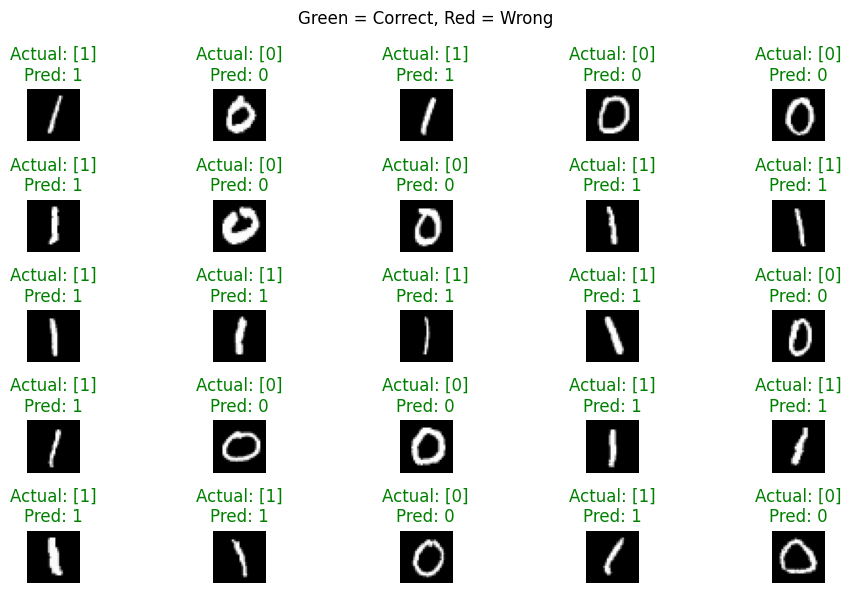

In [86]:
y_pred = (model.predict(X_test)>=0.5).astype(int)  #converting the boolean into integer, for checking whether the prediction done by our model is true or not
fig, axes = plt.subplots(5, 5, figsize=(10, 6))  # 3 rows, 5 columns

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    
    actual    = y_test[i]
    predicted = y_pred[i][0]
    
    # Green title if correct, Red if wrong
    color = 'green' if predicted == actual else 'red'
    ax.set_title(f'Actual: {actual}\nPred: {predicted}', c=color)
    ax.axis('off')

plt.suptitle('Green = Correct, Red = Wrong')
plt.tight_layout()
plt.show()